In [1]:
%matplotlib widget
import scipp as sc
from drtrex.instrument import Instrument
from drtrex.sample import Sample
from drtrex.components.source import Source


central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 16
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(facility="ess", neutrons=20_000_000, pulses=1)
res_elastic_rrm16 = trex.run()
sample = Sample(en={"uniform": (40, 50)})
res_inelastic_rrm16 = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_38554/1279856038.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


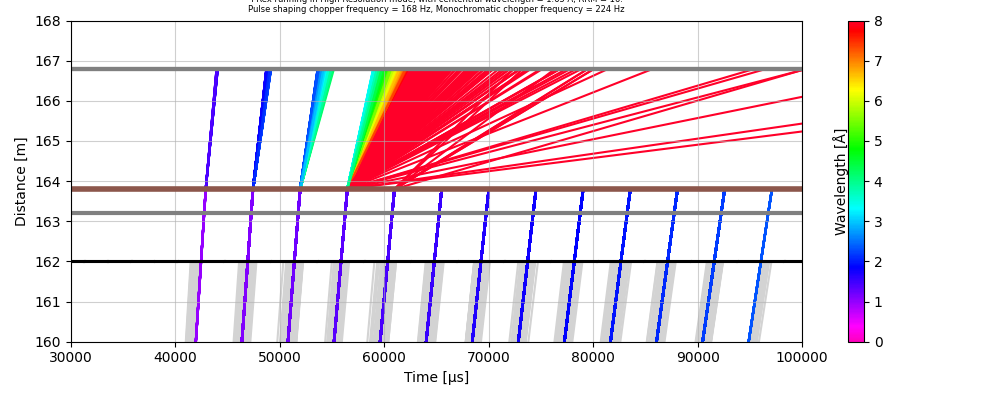

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm16.plot(
    visible_rays=20_000_000, blocked_rays=20_000, ax=ax, vmin=0, vmax=8
)
ax.set_xlim([30_000, 100_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

In [3]:
import plopp as pp
data = res_inelastic_rrm16.detectors['Detector'].data['pulse',0]
data = data[~data.masks["blocked_by_others"]]
pp.plot(data.hist(toa=1000),grid=True)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

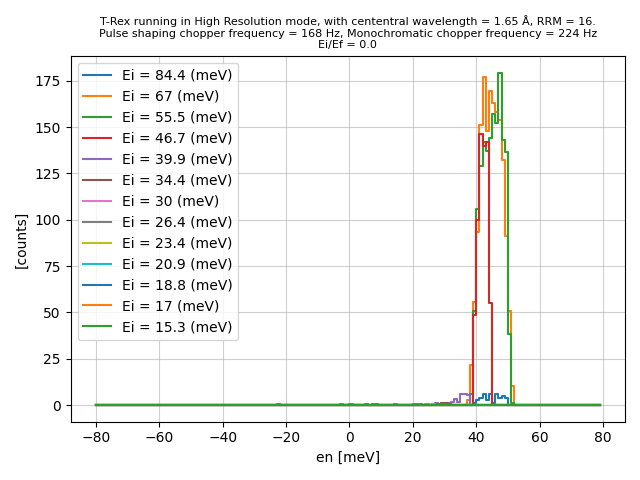

In [4]:
import plopp as pp

ei_ef_ratio = 0.0
params = trex.unwrap_frame(res_elastic_rrm16, ei_ef_ratio=ei_ef_ratio)
reduced_ins = trex.toa_to_energy(res_inelastic_rrm16, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords['kf_over_ki']
    reduced.data *= sc.sqrt(reduced.coords['ei']/reduced.coords['ef'])

hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_ins
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

In [5]:
reduced_ins[0]


<scipp.DataArray>
Dimensions: Sizes[pulse:1, event:647280, ]
Coordinates:
* birth_time                float64            [µs]  (pulse, event)  [797.851, 1865.18, ..., 1304.21, 3834.43]
* distance                  float64              [m]  ()  166.8
* ef                        float64            [meV]  (pulse, event)  [4.15117e+11, 2.46427e+11, ..., 2.29955, 2.29953]
* ei                        float64            [meV]  ()  84.3878
* en                        float64            [meV]  (pulse, event)  [-4.15117e+11, -2.46427e+11, ..., 82.0883, 82.0883]
* eto                       float64            [µs]  (pulse, event)  [42926.1, 42926.1, ..., 47449.1, 47449.1]
* id                          int64        <no unit>  (pulse, event)  [16106013, 7616928, ..., 6970137, 10011606]
* kf_over_ki                float64  [dimensionless]  (pulse, event)  [0.63492, 0.714175, ..., 0.546729, 0.687405]
* speed                     float64            [m/s]  (pulse, event)  [2539.86, 2922.05, ..., 2005.73, 2650.41]
* toa                       float64            [µs]  (pulse, event)  [42926.1, 42926.1, ..., 47449.1, 47449.1]
* wavelength                float64             [Å]  (pulse, event)  [1.55758, 1.35386, ..., 1.97237, 1.49261]
Data:
                            float64         [counts]  (pulse, event)  [9.05261e-06, 1.3216e-05, ..., 3.312, 4.16421]
Masks:
  blocked_by_others            bool        <no unit>  (pulse, event)  [True, True, ..., True, True]

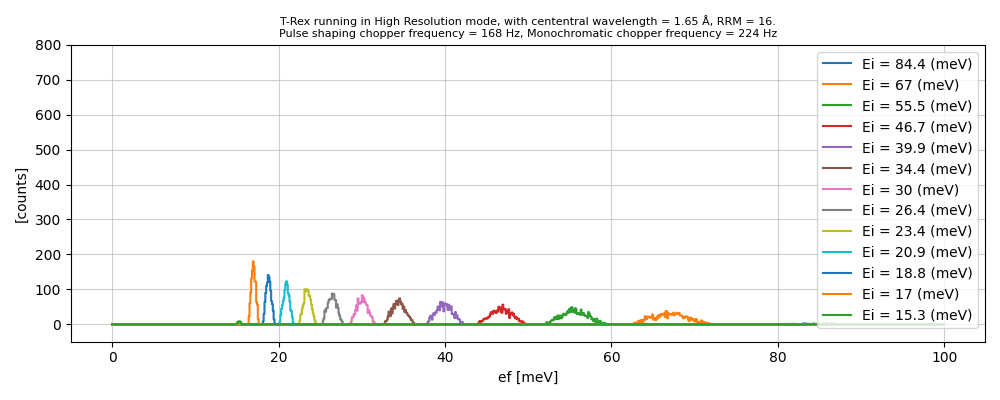

In [6]:
params = trex.unwrap_frame(res_elastic_rrm16, ei_ef_ratio=0.0)
reduced_elastic = trex.toa_to_energy(res_elastic_rrm16, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords['kf_over_ki']
    reduced.data *= sc.sqrt(reduced.coords['ei']/reduced.coords['ef'])
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 100, 0.1, unit="meV")
    )
    for reduced in reduced_elastic
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
ax.set_ylim([-50, 800])
fig.tight_layout()

In [7]:
central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 8
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(facility="ess", neutrons=20_000_000, pulses=1)
res_elastic_rrm8 = trex.run()
res_inelastic_rrm8 = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_38554/3328658655.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


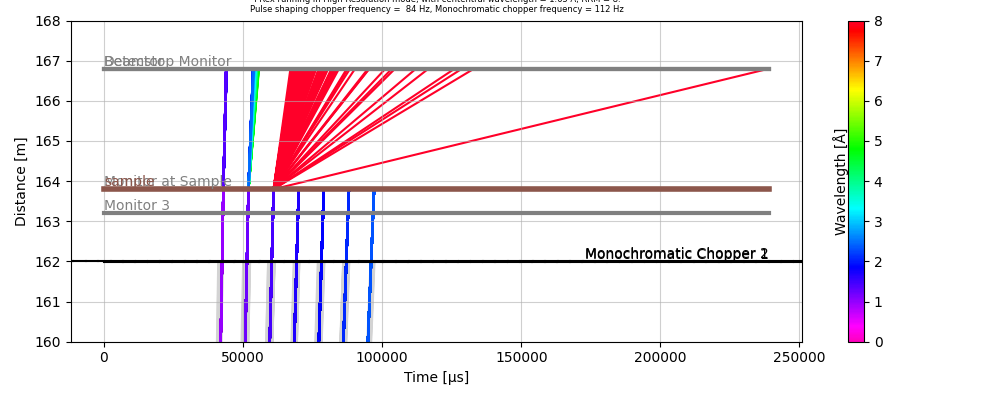

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm8.plot(
    visible_rays=2_000_000, blocked_rays=20_000, ax=ax, vmin=0, vmax=8
)
# ax.set_xlim([30_000, 100_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

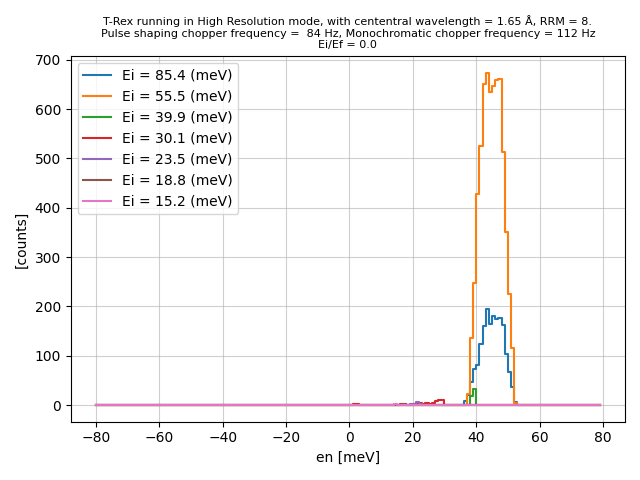

In [9]:
ei_ef_ratio = 0.0
params = trex.unwrap_frame(res_elastic_rrm8, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res_inelastic_rrm8, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords['kf_over_ki']
    reduced.data *= sc.sqrt(reduced.coords['ei']/reduced.coords['ef'])
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

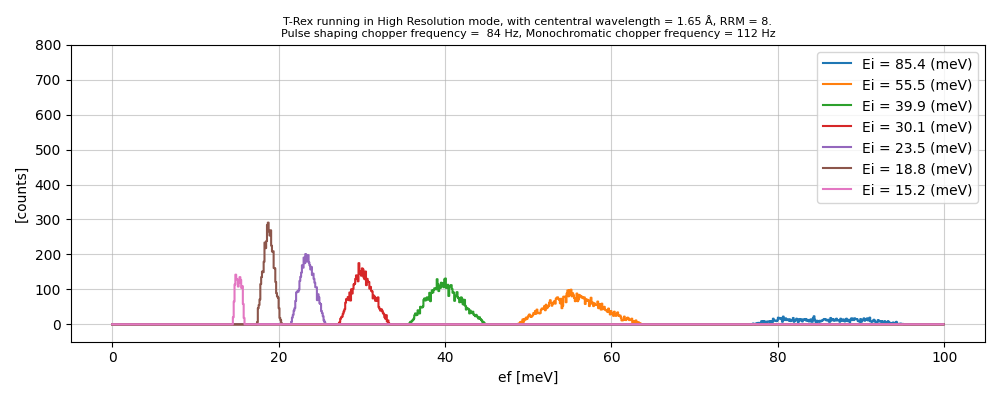

In [10]:
reduced_list = trex.toa_to_energy(res_elastic_rrm8, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords['kf_over_ki']
    reduced.data *= sc.sqrt(reduced.coords['ei']/reduced.coords['ef'])
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 100, 0.1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
ax.set_ylim([-50, 800])
fig.tight_layout()

In [11]:
central_wavelength = 1.65 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 4
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(facility="ess", neutrons=20_000_000, pulses=3)
res_elastic_rrm4 = trex.run()
res_inelastic_rrm4 = trex.run(sample)

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_38554/34098877.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


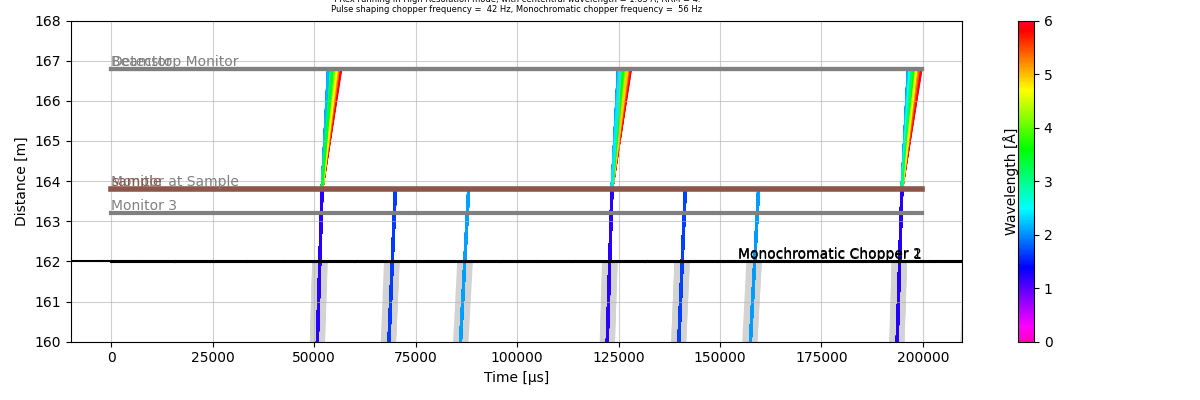

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))

res_inelastic_rrm4.plot(
    visible_rays=20_000_000, blocked_rays=20_000, ax=ax, vmin=0, vmax=6
)
# ax.set_xlim([30_000, 100_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

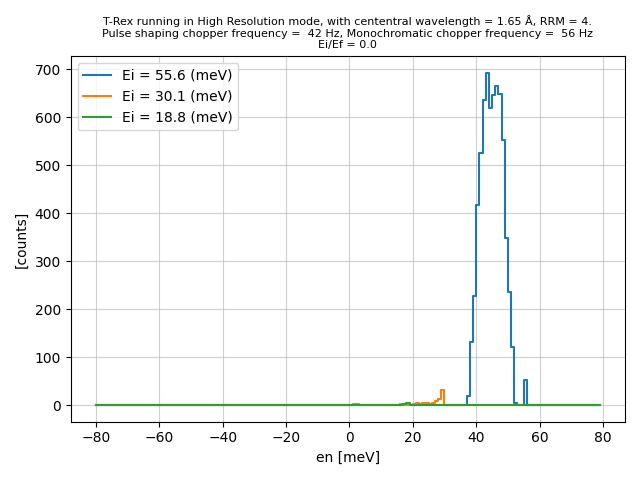

In [13]:
ei_ef_ratio = 0.0
trex.wrap_frame(res_elastic_rrm4)
params = trex.unwrap_frame(res_elastic_rrm4, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res_inelastic_rrm8, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords['kf_over_ki']
    reduced.data *= sc.sqrt(reduced.coords['ei']/reduced.coords['ef'])
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -80, 80, 1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

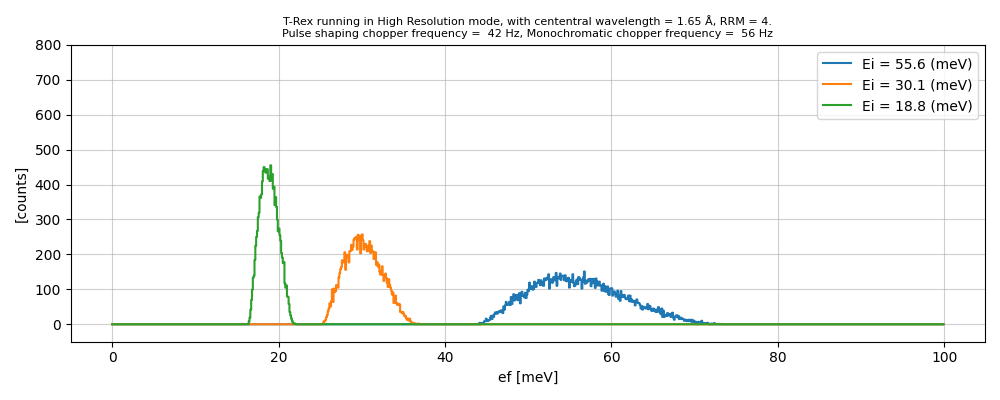

In [14]:
reduced_list = trex.toa_to_energy(res_elastic_rrm4, *params)
for reduced in reduced_ins:
    reduced.data *= reduced.coords['kf_over_ki']
    reduced.data *= sc.sqrt(reduced.coords['ei']/reduced.coords['ef'])
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        ef=sc.arange("ef", 0, 100, 0.1, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots(figsize=(10, 4))
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex), fontsize=8)
ax.grid(alpha=0.6)
ax.set_ylim([-50, 800])
fig.tight_layout()